This workbook walks through examples of creating data visualizations where one might not think to. This can include things like visually representing basic numbers or facts. Taking the time to visualize even simpler facts can help your audience absorb and retain the info. You're able to help them bridge the gap between text and human cognition. Including some flair elements to your visual can make this bridge even more effective.

This examples in this workbook focus on [the World's Largest Duck](https://thebigduck.us/). Which is fun, currently on tour, and has some really cool but basic stats that we can visualize. Below we'll make visualizations for the following:
- Where Mama Duck will be in July, 2026
- How many mallard ducks can fit inside Mama Duck
- How tall Mama Duck is compared to the Seneca One building in Buffalo, NY

In [1]:
# libraries for map
import base64
import os
import folium
# libraries for image comparison
from PIL import Image
import math
# library for comic-style graph
import matplotlib.pyplot as plt

**Map to show where Mama Duck will be in July 2026**

In [2]:
# For custom marker, function to encode a local PNG file to Base64
def get_base64_encoded_image(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Could not find the image at: {image_path}")
        
    with open(image_path, "rb") as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode("utf-8")
    return f"data:image/png;base64,{encoded_string}"

In [3]:
base64_icon_string = get_base64_encoded_image('rubber-duck-icon.png')

In [4]:
# Initialize map
m = folium.Map(location=[43.0792, -78.8268], zoom_start=5)

In [5]:
# Add locations and map labels
locations_data = [
    {"coords": [42.876903, -78.879351], "name": "07/03 - 07/05 | Buffalo, NY"},
    {"coords": [41.653608, -82.821333 ], "name": "07/10 - 07/12 | Put-in-Bay, OH"},
    {"coords": [44.05, -91.6391667], "name": "07/24 - 07/26 | Winona, MN"}
]

In [6]:
# Add locations, custom markers, and formatted + permanent labels
for item in locations_data:
    # Pass the Base64 data string directly into CustomIcon
    custom_icon = folium.CustomIcon(
        base64_icon_string, 
        icon_size=(100, 100) # Width and height in pixels
    )
    marker_tooltip = folium.Tooltip(
        item["name"], 
        permanent=True,
        style="font-size: 12px; font-weight: bold; background-color: white;"
    )
    
    # Add marker with permanent text label
    folium.Marker(
        location=item["coords"],
        icon=custom_icon,
        tooltip=marker_tooltip
    ).add_to(m)


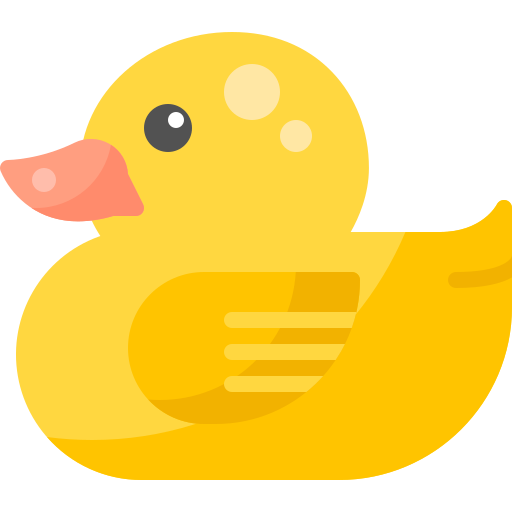
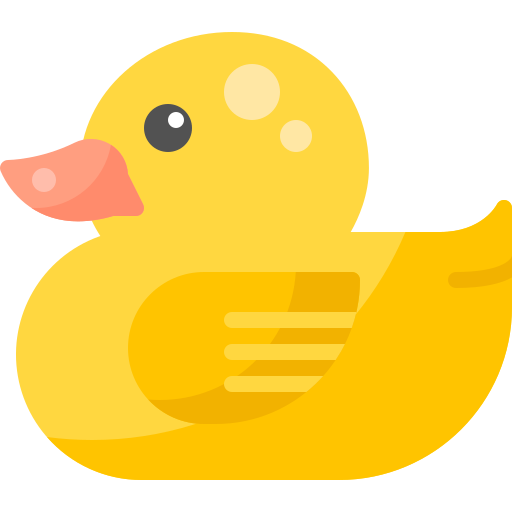
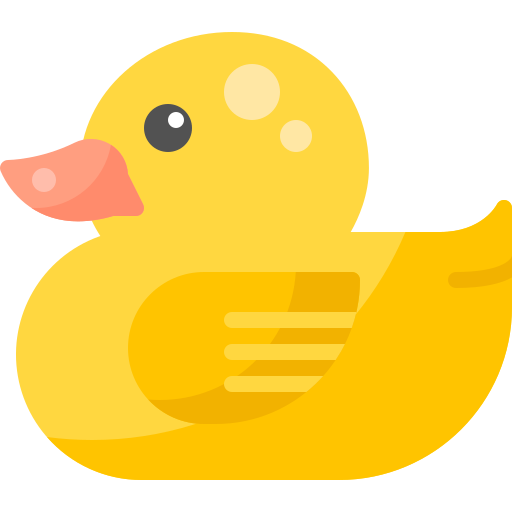

In [7]:
# Show and then save map
m

In [8]:
m.save("mama-duck-locations-202607.html")

**Show how many mallards can fit into Mama Duck**

In [9]:
# Identify images you'll be using
mama_duck_img = Image.open('mama-duck-big.jpg')
mallard_img = Image.open('mallard-duck-icon.png')
output_img = 'mama-to-mallard-comp.png'

In [10]:
# Set up main image and grid for smaller images
main_img = mama_duck_img
main_w, main_h = mama_duck_img.size
num_copies = 114

In [11]:
cols = 18
rows = (num_copies + cols - 1) // cols

In [12]:
item_w = 100
item_h = 100
small_resized = mallard_img.resize((item_w, item_h))

In [13]:
total_w = main_w + (cols * item_w)
total_h = max(main_h, rows * item_h)

final_img = Image.new('RGBA', (total_w, total_h), (0, 0, 0, 255))

In [14]:
final_img.paste(main_img, (0, 0))

In [15]:
# Plot images and show + save final image
start_x = main_w

for i in range(num_copies):
    current_col = i % cols
    current_row = i // cols
    
    # Calculate exact (x, y) coordinates
    x_offset = start_x + (current_col * item_w)
    y_offset = current_row * item_h
    
    final_img.paste(small_resized, (x_offset, y_offset))

# 6. Save the final result
final_img.save(output_img)
final_img.show()

**Compare Seneca One and Mama Duck height**

In [16]:
# Data
categories = ['Seneca One', 'Mama Duck']
stories = [40, 6]

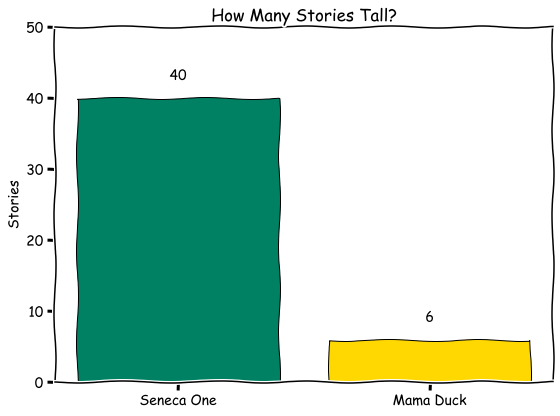

In [17]:
# Enable XKCD comic style + build graph + show + save
with plt.xkcd():
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create the bar graph
    bars = ax.bar(categories, stories, color=['#008163','#FFD801'], edgecolor='black')
    
    # Add labels and a sketchy title
    ax.set_title('How Many Stories Tall?')
    ax.set_ylabel('Stories')
    
    # Add exact values on top of the bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height}',
                ha='center', va='bottom')

    # Adjust layout to make it look clean
    plt.ylim(0,50)
    plt.tight_layout()
    plt.savefig('seneca-one-v-mama-duck.png', dpi=300, bbox_inches='tight')
    plt.show()